In [1]:
%pip install -q pandas numpy matplotlib scipy pyyaml

Note: you may need to restart the kernel to use updated packages.


# Layer Selection for Downstream Correlation Analysis

**Question:** Which layer's RankMe values should we use when correlating geometry with downstream performance (m-MMLU, XCOPA)?

**Approach:** For each layer we compute the **cross-language standard deviation of RankMe** (each language value averaged over all training checkpoints). A higher std means languages are more spread apart at that layer — more signal available to correlate with per-language outcomes.

The selected layers are then used in `notebooks/joao_pinto_407597.ipynb` for the peak-layer correlation analysis section.

In [2]:
%matplotlib inline

import os
import sys
from pathlib import Path

import pandas as pd

NOTEBOOK_DIR = Path(os.getcwd())
sys.path.insert(0, str(NOTEBOOK_DIR))

from utils import compute_stratification, plot_stratification, stratification_summary

print("Imports OK")

Imports OK


## Configuration

In [ ]:
REPO_ROOT   = NOTEBOOK_DIR.parent.parent
RESULTS_DIR = REPO_ROOT / "results"

MODELS = [
    dict(
        label     = "FuxiTranyu-8B",
        csv       = RESULTS_DIR / "fuxi_fine_wiki.csv",
        color     = "steelblue",
        model_key = "fuxi",
    ),
    dict(
        label     = "Apertus-8B-2509",
        csv       = RESULTS_DIR / "apertus_fine_wiki.csv",
        color     = "darkorange",
        model_key = "apertus",
    ),
]

for cfg in MODELS:
    if not cfg["csv"].exists():
        raise FileNotFoundError(f"{cfg['csv']} not found — run geometry_analysis.py first.")
    print(f"[{cfg['label']}] CSV found: {cfg['csv'].name}")

## Cross-Language Stratification by Layer

For each `(layer, language)` pair we average RankMe across **all training checkpoints**, then compute the **std across languages** at that layer.

- High std → languages are spread far apart → the layer encodes strong language-specific geometry → more signal for correlation analysis.
- Low std → languages have converged to similar representations → little per-language signal.

## Plot: Stratification Signal Across All Layers

The dashed coloured line marks the selected layer (peak std).

Plot saved to plots/layer_stratification.png


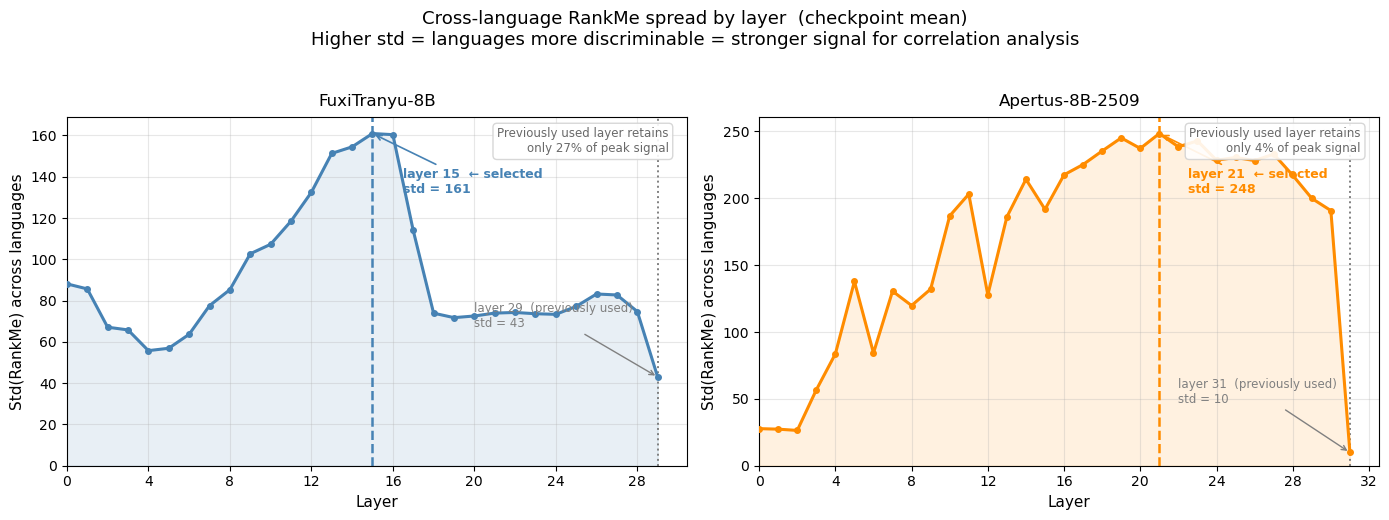

In [5]:
fig = plot_stratification(MODELS)
fig.savefig(NOTEBOOK_DIR / "plots" / "layer_stratification.png",
            dpi=150, bbox_inches="tight")
print("Plot saved to plots/layer_stratification.png")

## Findings

### FuxiTranyu-8B
- Peak stratification at **layer 15** (std = 160.9), closely followed by layer 16 (160.4) and layer 14 (154.5) — consistent with Pedro's finding of a mid-layer RankMe peak at layers 14–16.
- The signal drops sharply past layer 16 as language representations converge toward shared features in the deeper layers.

### Apertus-8B-2509
- Peak stratification at **layer 21** (std = 248.4), with layers 19–23 all close (237–245). This is in the upper-middle region of the monotone rise, just before the plateau.
- The signal collapses steeply beyond layer 21 as all languages converge to nearly identical RankMe values in the final layers.

### Conclusion
**Layer 15** (Fuxi) and **layer 21** (Apertus) are the layers of maximum cross-language differentiation and are used throughout `notebooks/joao_pinto_407597.ipynb` for all correlation and per-checkpoint analyses.

## Generating the New Merged CSVs

Run the following commands **on the cluster** (where `results/eval/` with the raw JSON files lives), from inside `/scratch/open-project-m2-jpmg`:

```bash
# FuxiTranyu-8B — layer 15
python code/downstream_evaluation/merge_results.py \
    --eval-dir  results/eval \
    --rankme-csv results/fuxi_fine_wiki.csv \
    --output    results/fuxi_fine_wiki_layer15_merged.csv \
    --layer layer_15 --aggregation last

# Apertus-8B-2509 — layer 21
python code/downstream_evaluation/merge_results.py \
    --eval-dir  results/eval \
    --rankme-csv results/apertus_fine_wiki.csv \
    --output    results/apertus_fine_wiki_layer21_merged.csv \
    --layer layer_21 --aggregation last
```

Then commit and push from the cluster, or copy the files locally. Once available, the new section in `notebooks/joao_pinto_407597.ipynb` will automatically use them.